# Proyecto de Machine Learning
## Predicción del precio de seguros para mascotas

# Notebook 03 – Evaluación

Este notebook recoge la **evaluación de los modelos** entrenados en el Notebook 02. Su objetivo es medir el rendimiento de cada modelo mediante métricas de regresión, compararlos de forma homogénea, analizar la interpretabilidad (qué variables influyen más en el precio) y seleccionar el modelo final.

> **Requisito previo:** haber ejecutado `01_preprocessing.ipynb` y `02_modeling.ipynb`, que generan el dataset preprocesado, la partición train/test y los modelos en `src/models/`.

# 1. Importación de librerías

Librerías necesarias para la carga de modelos/datos, el cálculo de métricas y la visualización de resultados.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

import joblib  # para cargar / guardar modelos

# 2. Configuración del entorno

Configuración de visualización para mantener un formato consistente durante la evaluación.

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
np.set_printoptions(suppress=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RUTA_DATA = "../data/"
RUTA_MODELS = "../models/"

# 3. Carga de modelos y conjunto de test

## Objetivo

Cargar los modelos entrenados en el Notebook 02 y la partición **train/test** generada durante el modelado (80/20, acordada por el equipo).

Se cargan también los datos de *train* porque se utilizarán en la sección 7 para comprobar si existe sobreajuste.

In [3]:
X_train = pd.read_pickle(RUTA_DATA + "X_train.pkl")
y_train = pd.read_pickle(RUTA_DATA + "y_train.pkl")
X_test  = pd.read_pickle(RUTA_DATA + "X_test.pkl")
y_test  = pd.read_pickle(RUTA_DATA + "y_test.pkl")

print("Train:", X_train.shape, "| Test:", X_test.shape)

modelos = {
    "Baseline (media)": joblib.load(RUTA_MODELS + "baseline.pkl"),
    "Regresión Lineal": joblib.load(RUTA_MODELS + "linear_regression.pkl"),
    "Ridge":            joblib.load(RUTA_MODELS + "ridge.pkl"),
    "Lasso":            joblib.load(RUTA_MODELS + "lasso.pkl"),
    "Elastic Net":      joblib.load(RUTA_MODELS + "elastic_net.pkl"),
    "Random Forest":    joblib.load(RUTA_MODELS + "random_forest.pkl"),
}

print("Modelos cargados:", list(modelos.keys()))

Train: (54000, 78) | Test: (13500, 78)
Modelos cargados: ['Baseline (media)', 'Regresión Lineal', 'Ridge', 'Lasso', 'Elastic Net', 'Random Forest']


# 4. Funciones de métricas

## Objetivo

Definir funciones reutilizables para calcular las métricas acordadas por el equipo: **MAE, RMSE, R² y MAPE**. Usar la misma función para todos los modelos garantiza que la comparación sea justa.

| Métrica | Qué mide | Lectura para negocio |
|---------|----------|----------------------|
| **MAE** | Error medio absoluto (en €) | Cuánto nos equivocamos de media, en euros |
| **RMSE** | Error cuadrático medio (en €) | Penaliza más los errores grandes |
| **R²** | Varianza explicada (0–1) | Qué parte de la variación del precio explica el modelo |
| **MAPE** | Error porcentual medio | Cuánto nos equivocamos de media, en % |

In [4]:
def calcular_metricas(y_true, y_pred):
    """Devuelve un diccionario con MAE, RMSE, R2 y MAPE para una predicción."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100  # en %

    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE (%)": mape}

# 5. Tabla comparativa de modelos

## Objetivo

Recoger las métricas de todos los modelos en una única tabla para compararlos de forma homogénea sobre el conjunto de **test**.

In [5]:
def construir_tabla_comparativa(modelos, X_test, y_test):
    """Calcula las métricas de cada modelo sobre test y devuelve un DataFrame
    comparativo ordenado por MAE (menor es mejor)."""
    filas = []
    for nombre, modelo in modelos.items():
        y_pred = modelo.predict(X_test)
        met = calcular_metricas(y_test, y_pred)
        met["Modelo"] = nombre
        filas.append(met)

    return (
        pd.DataFrame(filas)
        .set_index("Modelo")
        .sort_values("MAE")
        .round(4)
    )

In [6]:
tabla_resultados = construir_tabla_comparativa(modelos, X_test, y_test)
tabla_resultados

,MAE,RMSE,R2,MAPE (%)
Modelo,,,,
Random Forest,0.2305,0.4764,0.9980,0.6708
Ridge,1.7509,2.3437,0.9509,5.5421
Regresión Lineal,1.7515,2.3441,0.9509,5.5449
Elastic Net,5.5917,7.3887,0.5125,17.2814
Lasso,5.7620,7.6460,0.4779,17.8594
Baseline (media),8.3600,10.5821,-0.0000,27.6380


### Conclusiones

La tabla muestra tres niveles claramente diferenciados:

- **Baseline (media)**: sirve de suelo de referencia. Su R² es prácticamente cero, ya que se limita a predecir el precio medio.
- **Lasso y Elastic Net**: mejoran el baseline, pero explican solo aproximadamente la mitad de la variación del precio.
- **Regresión Lineal y Ridge**: alcanzan un rendimiento alto, con un R² en torno al 95 %.
- **Random Forest**: es claramente el mejor modelo, reduciendo el error medio muy por debajo del resto.

### Decisión

Se selecciona **Random Forest** como modelo candidato, pendiente de las comprobaciones de sobreajuste e interpretabilidad de las secciones siguientes.

In [7]:
# Modelo con mejor rendimiento según la tabla
mejor_modelo_nombre = tabla_resultados.index[0]
mejor_modelo = modelos[mejor_modelo_nombre]

y_pred_mejor = mejor_modelo.predict(X_test)

print("Modelo seleccionado:", mejor_modelo_nombre)

Modelo seleccionado: Random Forest


# 6. Visualizaciones

## Objetivo

Apoyar la comparación y la interpretación de resultados con gráficos.

## 6.1 Comparativa de métricas entre modelos

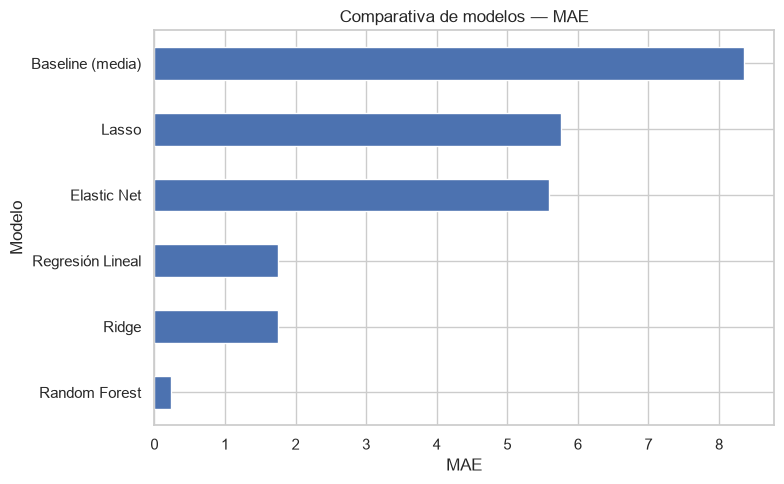

In [8]:
def graficar_comparativa_metricas(tabla, metrica="MAE"):
    """Gráfico de barras comparando una métrica entre todos los modelos."""
    orden = tabla[metrica].sort_values(ascending=(metrica != "R2"))
    ax = orden.plot(kind="barh")
    ax.set_title(f"Comparativa de modelos — {metrica}")
    ax.set_xlabel(metrica)
    plt.tight_layout()
    plt.show()


graficar_comparativa_metricas(tabla_resultados, "MAE")

## 6.2 Valores reales vs. predichos

Permite ver visualmente cómo de cerca quedan las predicciones de la realidad: la nube ideal se pega a la diagonal roja.

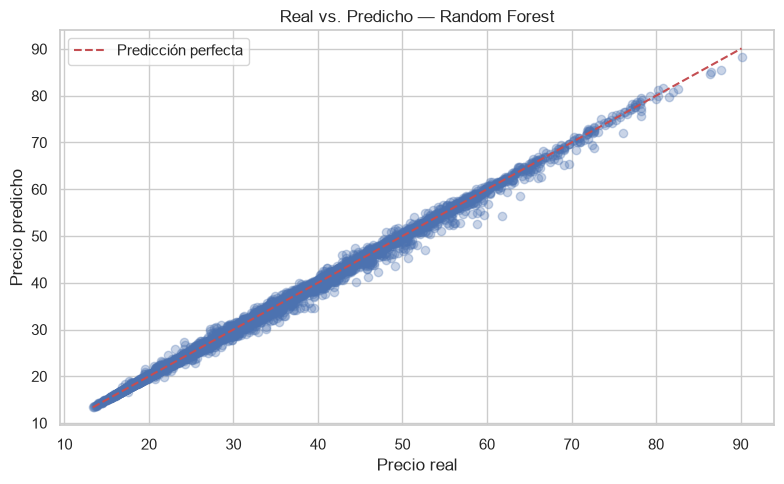

In [9]:
def graficar_real_vs_predicho(y_true, y_pred, titulo="Real vs. Predicho"):
    plt.scatter(y_true, y_pred, alpha=0.3)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, "r--", label="Predicción perfecta")
    plt.xlabel("Precio real")
    plt.ylabel("Precio predicho")
    plt.title(titulo)
    plt.legend()
    plt.tight_layout()
    plt.show()


graficar_real_vs_predicho(y_test, y_pred_mejor, f"Real vs. Predicho — {mejor_modelo_nombre}")

## 6.3 Distribución de residuos

Los residuos (real − predicho) deberían repartirse alrededor de 0 sin patrones claros.

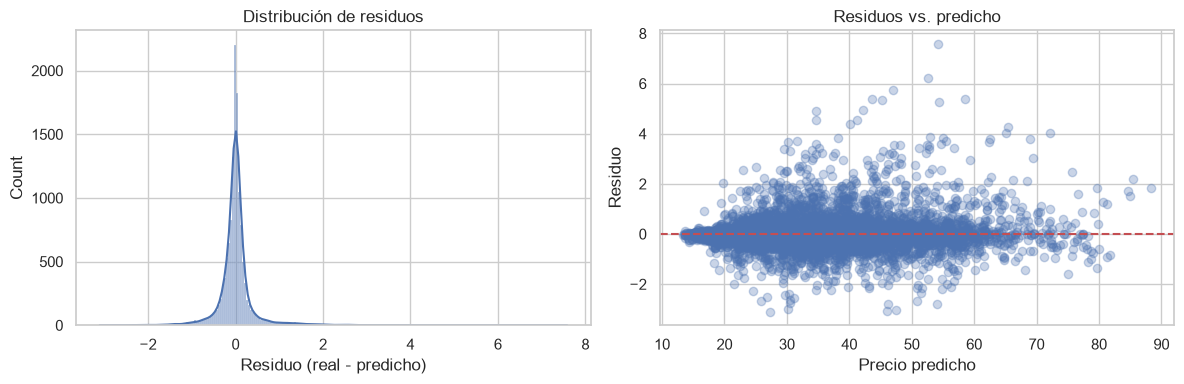

In [10]:
def graficar_residuos(y_true, y_pred):
    residuos = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(residuos, kde=True, ax=axes[0])
    axes[0].set_title("Distribución de residuos")
    axes[0].set_xlabel("Residuo (real - predicho)")
    axes[1].scatter(y_pred, residuos, alpha=0.3)
    axes[1].axhline(0, color="r", linestyle="--")
    axes[1].set_title("Residuos vs. predicho")
    axes[1].set_xlabel("Precio predicho")
    axes[1].set_ylabel("Residuo")
    plt.tight_layout()
    plt.show()


graficar_residuos(y_test, y_pred_mejor)

## 6.4 Importancia de variables

Responde a la pregunta clave del negocio: **¿qué variables influyen más en el precio del seguro?**

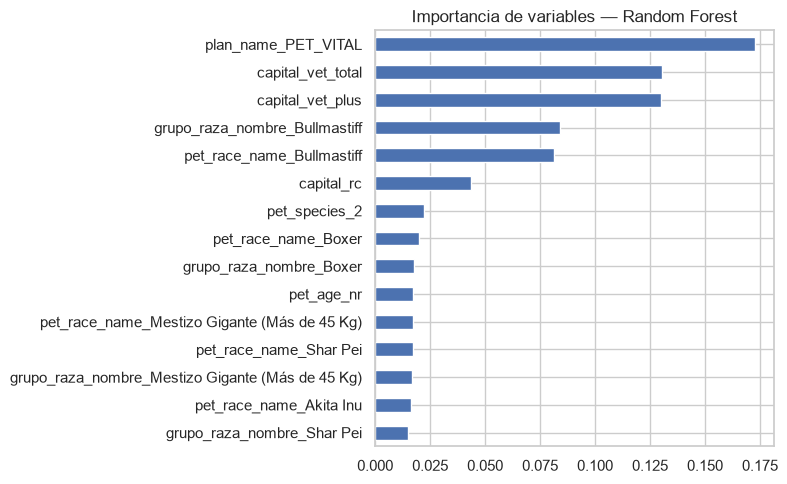

plan_name_PET_VITAL                                 0.172732
capital_vet_total                                   0.130322
capital_vet_plus                                    0.129959
grupo_raza_nombre_Bullmastiff                       0.084098
pet_race_name_Bullmastiff                           0.081428
capital_rc                                          0.043372
pet_species_2                                       0.022406
pet_race_name_Boxer                                 0.020148
grupo_raza_nombre_Boxer                             0.017477
pet_age_nr                                          0.017403
pet_race_name_Mestizo Gigante (Más de 45 Kg)        0.017330
pet_race_name_Shar Pei                              0.017226
grupo_raza_nombre_Mestizo Gigante (Más de 45 Kg)    0.016560
pet_race_name_Akita Inu                             0.016145
grupo_raza_nombre_Shar Pei                          0.014959
dtype: float64

In [11]:
def graficar_importancia(modelo, nombres_variables, top=15):
    """Muestra la importancia de variables (árboles) o los coeficientes (lineales)."""
    if hasattr(modelo, "feature_importances_"):
        valores = modelo.feature_importances_
        titulo = "Importancia de variables"
    elif hasattr(modelo, "coef_"):
        valores = np.abs(modelo.coef_)
        titulo = "Coeficientes (valor absoluto)"
    else:
        print("El modelo no expone importancia de variables ni coeficientes.")
        return

    imp = (
        pd.Series(valores, index=nombres_variables)
        .sort_values(ascending=False)
        .head(top)
    )
    imp.sort_values().plot(kind="barh")
    plt.title(f"{titulo} — {mejor_modelo_nombre}")
    plt.tight_layout()
    plt.show()
    return imp


importancias = graficar_importancia(mejor_modelo, X_test.columns)
importancias

# 7. Revisión de sobreajuste (train vs. test)

## Objetivo

Comparar el rendimiento en **train** y en **test**. Una diferencia grande a favor de train indicaría sobreajuste (overfitting).

In [12]:
def comparar_train_test(modelos, X_train, y_train, X_test, y_test, metrica="R2"):
    filas = []
    for nombre, modelo in modelos.items():
        m_train = calcular_metricas(y_train, modelo.predict(X_train))[metrica]
        m_test  = calcular_metricas(y_test,  modelo.predict(X_test))[metrica]
        filas.append({
            "Modelo": nombre,
            f"{metrica}_train": m_train,
            f"{metrica}_test": m_test,
            "Diferencia": m_train - m_test,
        })
    return pd.DataFrame(filas).set_index("Modelo").round(4)


comparacion_overfitting = comparar_train_test(modelos, X_train, y_train, X_test, y_test)
comparacion_overfitting

,R2_train,R2_test,Diferencia
Modelo,,,
Baseline (media),0.0000,-0.0000,0.0000
Regresión Lineal,0.9515,0.9509,0.0006
Ridge,0.9516,0.9509,0.0006
Lasso,0.4820,0.4779,0.0040
Elastic Net,0.5163,0.5125,0.0039
Random Forest,0.9997,0.9980,0.0018


### Conclusiones

La diferencia entre el rendimiento en train y en test es mínima, por lo que **no se observa sobreajuste relevante**.

Además, durante el preprocesamiento se excluyó `precio_anual` por tratarse de una transformación directa de la variable objetivo, evitando así el **Data Leakage** que habría falseado los resultados.

# 8. Selección del modelo final y persistencia

## Objetivo

Guardar el modelo seleccionado en `src/models` en formato `joblib`, tal como exige la guía del proyecto.

In [13]:
joblib.dump(mejor_modelo, RUTA_MODELS + "modelo_final.pkl")
print(f"Modelo final ({mejor_modelo_nombre}) guardado en {RUTA_MODELS}modelo_final.pkl")

Modelo final (Random Forest) guardado en ../models/modelo_final.pkl


# 9. Conclusiones

**Modelo seleccionado: Random Forest.**

- Es el modelo con mejor rendimiento sobre el conjunto de test, muy por encima del baseline y de los modelos lineales.
- No presenta sobreajuste: el rendimiento en train y test se mantiene.
- Se ha descartado el riesgo de *Data Leakage* al excluir `precio_anual` del conjunto de variables predictoras.

**Interpretación para el negocio**

- El modelo permite estimar el precio de una nueva cotización con un error medio muy reducido.
- La importancia de variables muestra qué factores pesan más en el cálculo del precio, que era el segundo objetivo planteado por el negocio.

**Consideración metodológica**

El dataset está construido mediante combinaciones controladas de perfiles y coberturas, por lo que un R² tan elevado es coherente con la naturaleza del conjunto de datos, pero **debe interpretarse con cautela**: no garantiza el mismo comportamiento sobre cotizaciones reales de mercado.

**Acciones de mejora**

- Validar el modelo con cotizaciones reales ajenas a esta matriz para confirmar su capacidad de generalización.
- Ampliar el histórico temporal para evaluar si la fecha de cotización aporta información (actualmente solo abarca once días).